**Name: Lucas Jones**

**Homework 3 - CSCI 347 Data Mining**


Show your work. Include any code snippets that you used to generate
answers. Complete this assignment individually. Unless otherwise
stated, you can use code snippets to generate answers. If you are asked
to do the calculations by hand, include your working.

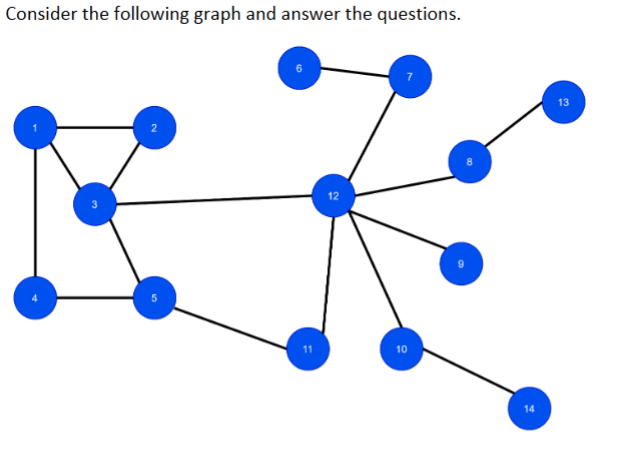

1. [5 points] First, **without using** networkx or any other graph
analysis packages (You may use them to check the answer), find
the closeness centrality of vertices 5, 11, 3, and 12

![Problem 1.png](prob_1.png)

2. [4 points] **without using networkx** or any other graph packages,
find the eccentricity of vertices 5 and 12.


![prob 2.png](prob_2.png)

3. [3 points] Find the betweenness centrality of vertices 5, 11, 3, 12.
You may use **networkx** or any other graph packages. You **must
include** the code snippet used to generate the answers. (You can
include the code in a separate document and turn it into Canvas
or include code snippets in this document.)

In [1]:
import networkx as nx

G = nx.Graph()

G.add_edges_from([(1,2), (1,3), (1,4), (2,3), (3,5), (3,12), (4,5), (5,11), (6,7), (7,12), (8,13), (8,12), (9,12), (10,12), (10,14), (11,12)])

centrality_scores = nx.betweenness_centrality(G)

for node, score in centrality_scores.items():
    if node in [5, 11, 3, 12]:
        print(f"Node {node}: {score:.4f}")


Node 3: 0.3654
Node 5: 0.1090
Node 12: 0.7863
Node 11: 0.0855


4. [3 points] Using **networkx**, find the prestige/eigenvector
centrality of vertices 5, 11, 3, and 12. Include code snippet used to
generate the answers.

In [2]:
eigenvector_centrality_scores = nx.eigenvector_centrality(G)

for node, score in eigenvector_centrality_scores.items():
    if node in [5, 11, 3, 12]:
        print(f"Node {node}: {score:.4f}")

Node 3: 0.4687
Node 5: 0.3212
Node 12: 0.4922
Node 11: 0.2731


5. [3 points] Find the average path length between two vertices in
this graph, 𝜇𝐿.

In [3]:
all_paths = list(nx.all_simple_paths(G, source=1, target=12))
lenghts = [len(path) - 1 for path in all_paths]
avg_length = sum(lenghts) / len(lenghts)

print(f"Average path length : {avg_length:.4f}")

Average path length : 3.6667


6. [3 points] Create a plot that shows the degree distribution of the
graph. Include the code snippet used to generate the answer as
well as the final plot.

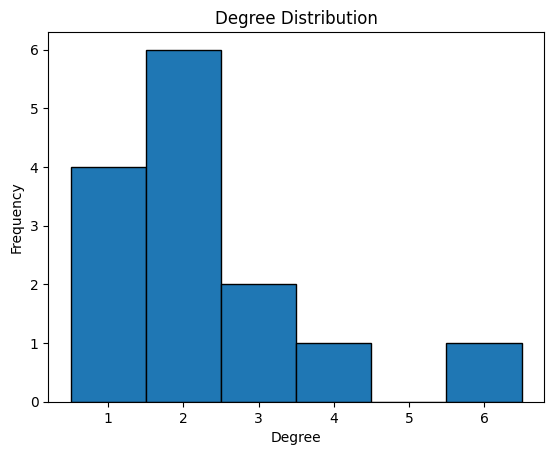

In [4]:
import matplotlib.pyplot as plt 

degrees = [d for n, d in G.degree()]

plt.hist(degrees, bins=range(1, max(degrees) + 2), align='left', edgecolor='black')
plt.title('Degree Distribution')
plt.xlabel('Degree')
plt.ylabel('Frequency')
plt.show()

7. [3 points] **Without using** networkx or any other libraries find the
clustering coefficient of the vertex 5. (You may use coding to
check the answer).


![prob 7.png](prob_7.png)

8. [4 points] Find the clustering coefficient of the entire graph
**without using coding** (You may use coding to check the answer).

![prob 8.png](prob_8.png)

9. [4 points] Using networkx or any other library, create an
(undirected) watts strogatz graph with parameters n=200, k =4,
and p=0.1. Create a visualization of the graph, with vertex sizes
dependent on betweenness centrality (the higher the
betweenness centrality, the greater the size) and node color
dependent on degree. Include both the code to generate the
plots, as well as the plots, in your submission. Make sure the max
and min size used for node sizes is not too overwhelming—try
different sizes and pick something that works. You can pick any
color scheme that you like for the degrees.


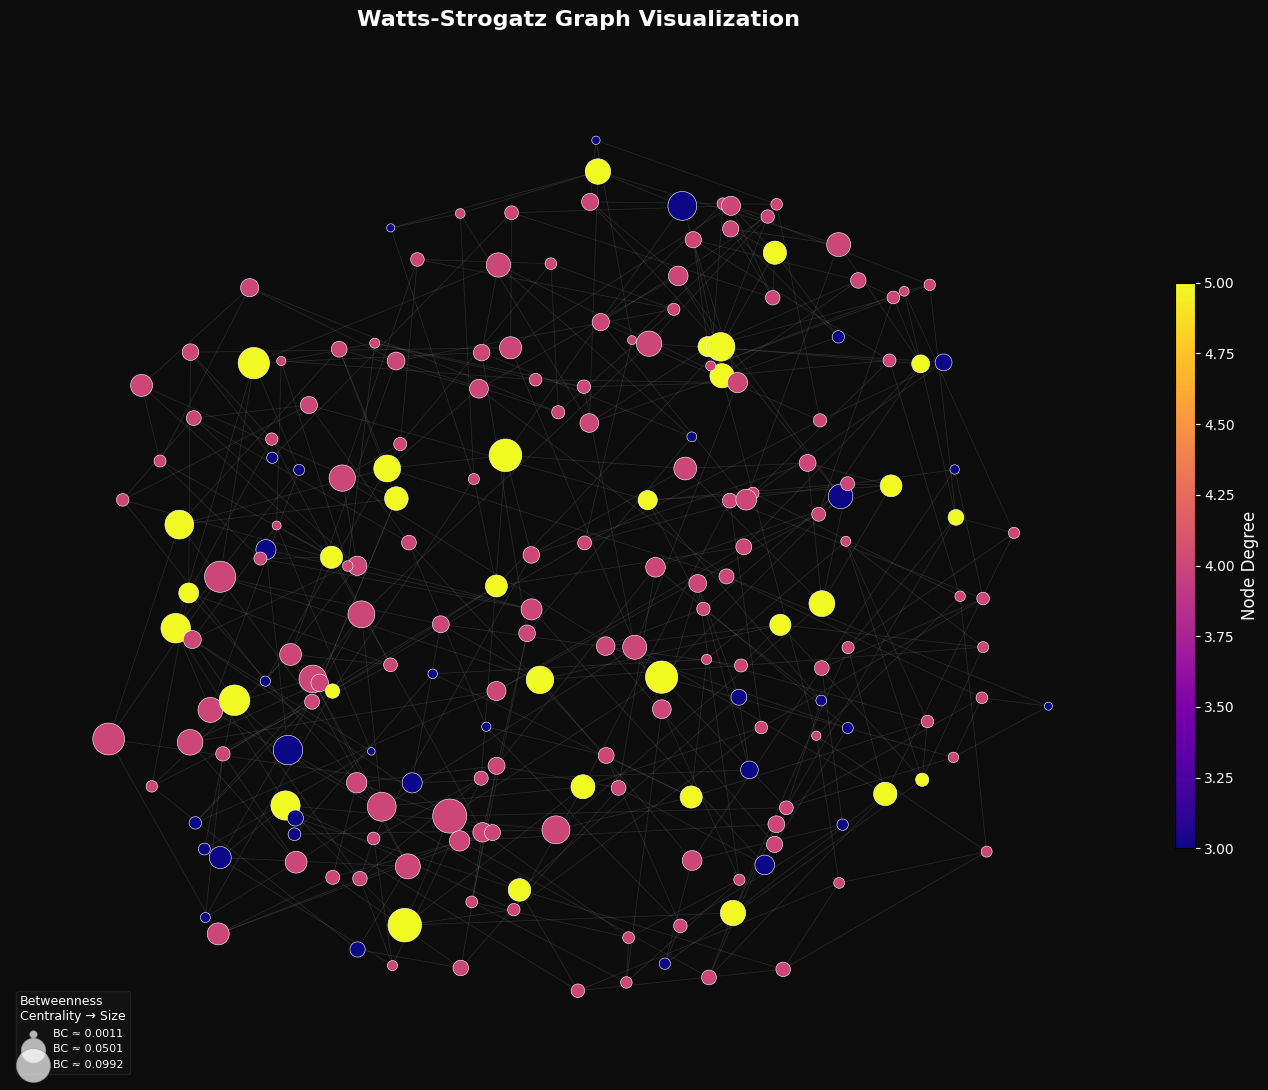

In [5]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

np.random.seed(42)
G = nx.watts_strogatz_graph(n=200, k=4, p=0.1, seed=42)

betweenness = nx.betweenness_centrality(G)
degrees = dict(G.degree())

bc_vals = np.array([betweenness[n] for n in G.nodes()])
bc_min, bc_max = bc_vals.min(), bc_vals.max()
size_min, size_max = 30, 600
if bc_max > bc_min:
    node_sizes = size_min + (bc_vals - bc_min) / (bc_max - bc_min) * (size_max - size_min)
else:
    node_sizes = np.full(len(bc_vals), (size_min + size_max) / 2)

deg_vals = np.array([degrees[n] for n in G.nodes()])
cmap = plt.cm.plasma
norm = mcolors.Normalize(vmin=deg_vals.min(), vmax=deg_vals.max())
node_colors = [cmap(norm(d)) for d in deg_vals]

pos = nx.spring_layout(G, seed=42, k=0.45)

fig, ax = plt.subplots(figsize=(14, 11), facecolor='#0d0d0d')  # fixed: facecolor + #
ax.set_facecolor('#0d0d0d')  # fixed: added #

nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.18, width=0.55, edge_color='#aaaaaa')  # fixed: added #
nx.draw_networkx_nodes(G, pos, ax=ax, node_size=node_sizes, node_color=node_colors,
                       linewidths=0.4, edgecolors="#ffffff")

ax.set_title('Watts-Strogatz Graph Visualization', fontsize=16, fontweight="bold", color='white', pad=18)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.55, pad=0.02, aspect=28)
cbar.set_label("Node Degree", color="white", fontsize=12)
cbar.ax.yaxis.set_tick_params(color="white")
plt.setp(cbar.ax.yaxis.get_ticklabels(), color="white")

legend_bc  = [bc_min, (bc_min + bc_max) / 2, bc_max]
legend_sz  = [size_min, (size_min + size_max) / 2, size_max]
legend_lbl = [f"{v:.4f}" for v in legend_bc]
legend_handles = [
    plt.scatter([], [], s=s, c="white", alpha=0.7, edgecolors="#888888", linewidths=0.5,
                label=f"BC ≈ {lbl}")
    for s, lbl in zip(legend_sz, legend_lbl)
]
ax.legend(
    handles=legend_handles,
    title="Betweenness\nCentrality → Size",
    title_fontsize=9,
    fontsize=8,
    loc="lower left",
    framealpha=0.25,
    labelcolor="white",
    facecolor="#222222",
    edgecolor="#555555"
)
ax.legend_.get_title().set_color("white")

ax.axis("off")
plt.tight_layout()
plt.show()
